In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/xai_project'
os.chdir(PROJECT_ROOT)
print(f'Working directory: {os.getcwd()}')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/xai_project


In [ ]:
!pip install timm albumentations torchmetrics -q

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.8 MB/s eta 0:00:00
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [ ]:
import sys
sys.path.append('.')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.models as models
import timm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, classification_report

from src.preprocessing.preprocess import (
    ISICDataset, ChestXrayDataset,
    get_train_transforms, get_val_transforms,
    ISIC_LABELS, CHESTXRAY_LABELS,
    split_isic, split_chestxray,
)

CHESTXRAY_ROOT = 'data/chestxray'
ISIC_ROOT      = 'data/isic'
MODELS_DIR     = Path('outputs/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-4
NUM_WORKERS = 2
SEED        = 42
DEVICE      = 'cuda'

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config ready.')

Config ready.


In [ ]:
def build_isic_df_fixed(data_root):
    from pathlib import Path
    import numpy as np
    import pandas as pd
    ISIC_LABELS = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
    data_root = Path(data_root)
    gt = pd.read_csv(data_root / 'ISIC_2019_Training_GroundTruth.csv')
    img_dir = data_root / 'ISIC_2019_Training_Input' / 'ISIC_2019_Training_Input'
    records = []
    for _, row in gt.iterrows():
        img_path = img_dir / f"{row['image']}.jpg"
        if not img_path.exists():
            continue
        label_idx = int(np.argmax(row[ISIC_LABELS].values))
        records.append({
            'image_path': str(img_path),
            'label': label_idx,
            'class_name': ISIC_LABELS[label_idx],
        })
    df = pd.DataFrame(records)
    print(f'Loaded {len(df):,} ISIC images')
    return df

df_is = build_isic_df_fixed(ISIC_ROOT)
train_df, val_df, test_df = split_isic(df_is)

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(
    1.0 / class_counts * class_counts.sum() / len(class_counts),
    dtype=torch.float32
).to(DEVICE)

train_ds = ISICDataset(train_df, transform=get_train_transforms())
val_ds   = ISICDataset(val_df,   transform=get_val_transforms())
test_ds  = ISICDataset(test_df,  transform=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Class weights: {class_weights.cpu().numpy().round(2)}')

Loaded 23,347 ISIC images
Train: 18,677  Val: 2,335  Test: 2,335
Class weights: [ 0.72  0.24  1.02  3.87  1.2  13.49 13.12  5.18]


In [ ]:
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'efficientnet_b3':
        model = timm.create_model('efficientnet_b3', pretrained=pretrained, num_classes=num_classes)
    elif model_name == 'vit_b16':
        model = timm.create_model('vit_base_patch16_224', pretrained=pretrained, num_classes=num_classes)
    else:
        raise ValueError(f'Unknown model: {model_name}')
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'{model_name}: {total_params:.1f}M parameters')
    return model.to(DEVICE)

# Preview all three
for name in ['resnet50', 'efficientnet_b3', 'vit_b16']:
    m = get_model(name, num_classes=8)
    del m
    torch.cuda.empty_cache()
print('All models verified.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


resnet50: 23.5M parameters


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

efficientnet_b3: 10.7M parameters


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

vit_b16: 85.8M parameters
All models verified.


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    criterion = nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    try:
        auc = roc_auc_score(
            np.eye(8)[all_labels], all_probs, multi_class='ovr', average='macro'
        )
    except:
        auc = 0.0
    return total_loss / total, correct / total, auc


def train_model(model_name, num_classes, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, class_weights=None):
    print(f'\n{"="*55}')
    print(f'  Training: {model_name}')
    print(f'{"="*55}')
    model = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_auc':[]}
    best_auc = 0.0
    best_path = MODELS_DIR / f'{model_name}_best.pth'
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, vl_auc = evaluate(model, val_loader)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        print(f'Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  '
              f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  AUC: {vl_auc:.4f}')
        if vl_auc > best_auc:
            best_auc = vl_auc
            torch.save({
                'epoch': epoch,
                'model_name': model_name,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_auc': best_auc,
                'num_classes': num_classes,
            }, best_path)
            print(f'  ✓ Best model saved (AUC: {best_auc:.4f})')
    print(f'\n✓ Training complete. Best Val AUC: {best_auc:.4f}')
    return model, history


def plot_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Val')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_acc'],   'r-', label='Val')
    axes[1].set_title(f'{model_name} — Accuracy'); axes[1].legend()
    axes[2].plot(epochs, history['val_auc'], 'g-', label='Val AUC')
    axes[2].set_title(f'{model_name} — AUC-ROC'); axes[2].legend()
    plt.suptitle(f'{model_name} Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

print('Training functions ready.')

Training functions ready.


In [ ]:
import os

# Don't copy — just point directly to Drive
ISIC_ROOT = '/content/drive/MyDrive/xai_project/data/isic'

# Rebuild DataLoaders directly from Drive
df_is = build_isic_df_fixed(ISIC_ROOT)
train_df, val_df, test_df = split_isic(df_is)

train_ds = ISICDataset(train_df, transform=get_train_transforms())
val_ds   = ISICDataset(val_df,   transform=get_val_transforms())
test_ds  = ISICDataset(test_df,  transform=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print('✓ DataLoaders ready')

Loaded 23,347 ISIC images
Train: 18,677  Val: 2,335  Test: 2,335
✓ DataLoaders ready



  Training: resnet50
resnet50: 23.5M parameters


Epoch [01/15]  Train Loss: 1.4721  Acc: 0.5477  |  Val Loss: 1.0452  Acc: 0.6231  AUC: 0.9096
  ✓ Best model saved (AUC: 0.9096)


Epoch [02/15]  Train Loss: 1.1160  Acc: 0.6115  |  Val Loss: 0.9424  Acc: 0.6535  AUC: 0.9204
  ✓ Best model saved (AUC: 0.9204)


Epoch [03/15]  Train Loss: 0.9712  Acc: 0.6490  |  Val Loss: 0.8291  Acc: 0.6989  AUC: 0.9386
  ✓ Best model saved (AUC: 0.9386)


Epoch [04/15]  Train Loss: 0.8585  Acc: 0.6775  |  Val Loss: 0.6813  Acc: 0.7593  AUC: 0.9515
  ✓ Best model saved (AUC: 0.9515)


...

Epoch [11/15]  Train Loss: 0.3480  Acc: 0.8301  |  Val Loss: 0.5728  Acc: 0.8073  AUC: 0.9657


Epoch [12/15]  Train Loss: 0.3032  Acc: 0.8436  |  Val Loss: 0.5789  Acc: 0.8060  AUC: 0.9646


Epoch [13/15]  Train Loss: 0.2778  Acc: 0.8557  |  Val Loss: 0.5900  Acc: 0.8090  AUC: 0.9626


Epoch [14/15]  Train Loss: 0.2614  Acc: 0.8622  |  Val Loss: 0.5561  Acc: 0.8184  AUC: 0.9682
  ✓ Best model saved (AUC: 0.9682)


Epoch [15/15]  Train Loss: 0.2525  Acc: 0.8665  |  Val Loss: 0.5637  Acc: 0.8163  AUC: 0.9669

✓ Training complete. Best Val AUC: 0.9682


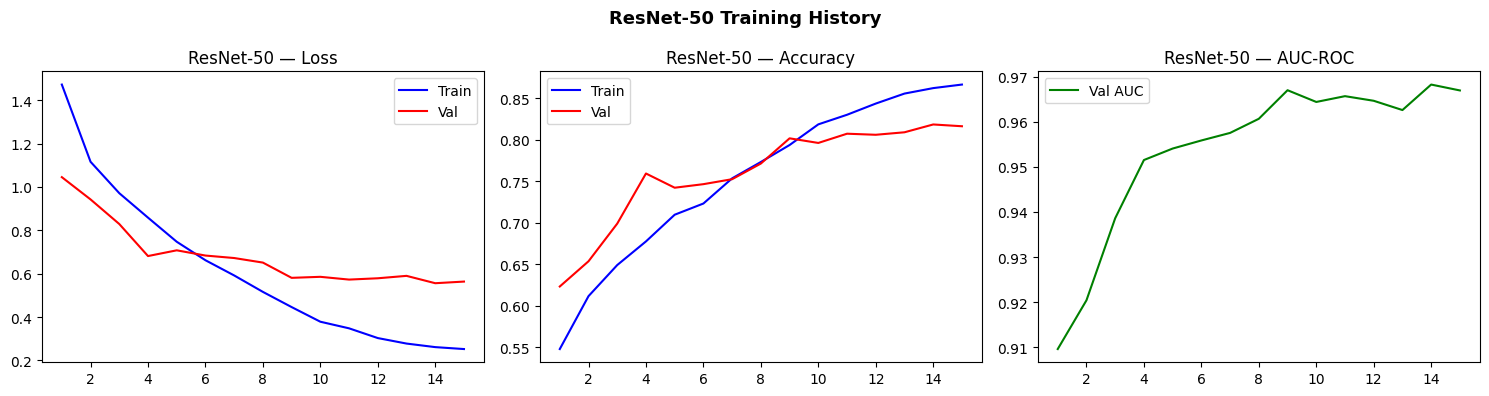

In [ ]:
resnet_model, resnet_history = train_model(
    model_name    = 'resnet50',
    num_classes   = 8,
    train_loader  = train_loader,
    val_loader    = val_loader,
    num_epochs    = NUM_EPOCHS,
    class_weights = class_weights,
)
plot_history(resnet_history, 'ResNet-50',
             save_path='outputs/reports/resnet50_isic_history.png')


  Training: efficientnet_b3


efficientnet_b3: 10.7M parameters


Epoch [01/15]  Train Loss: 1.9212  Acc: 0.4067  |  Val Loss: 1.2202  Acc: 0.5512  AUC: 0.8817
  ✓ Best model saved (AUC: 0.8817)


Epoch [02/15]  Train Loss: 1.2234  Acc: 0.5603  |  Val Loss: 1.0263  Acc: 0.6180  AUC: 0.9141
  ✓ Best model saved (AUC: 0.9141)


Epoch [03/15]  Train Loss: 1.0449  Acc: 0.6130  |  Val Loss: 0.8633  Acc: 0.6861  AUC: 0.9350
  ✓ Best model saved (AUC: 0.9350)


...

Epoch [11/15]  Train Loss: 0.3435  Acc: 0.8326  |  Val Loss: 0.6323  Acc: 0.7906  AUC: 0.9636
  ✓ Best model saved (AUC: 0.9636)


Epoch [12/15]  Train Loss: 0.3138  Acc: 0.8447  |  Val Loss: 0.6544  Acc: 0.7829  AUC: 0.9619


Epoch [13/15]  Train Loss: 0.2934  Acc: 0.8478  |  Val Loss: 0.6369  Acc: 0.7927  AUC: 0.9624


Epoch [14/15]  Train Loss: 0.2799  Acc: 0.8570  |  Val Loss: 0.6226  Acc: 0.7957  AUC: 0.9633


Epoch [15/15]  Train Loss: 0.2815  Acc: 0.8550  |  Val Loss: 0.6259  Acc: 0.7949  AUC: 0.9640
  ✓ Best model saved (AUC: 0.9640)

✓ Training complete. Best Val AUC: 0.9640


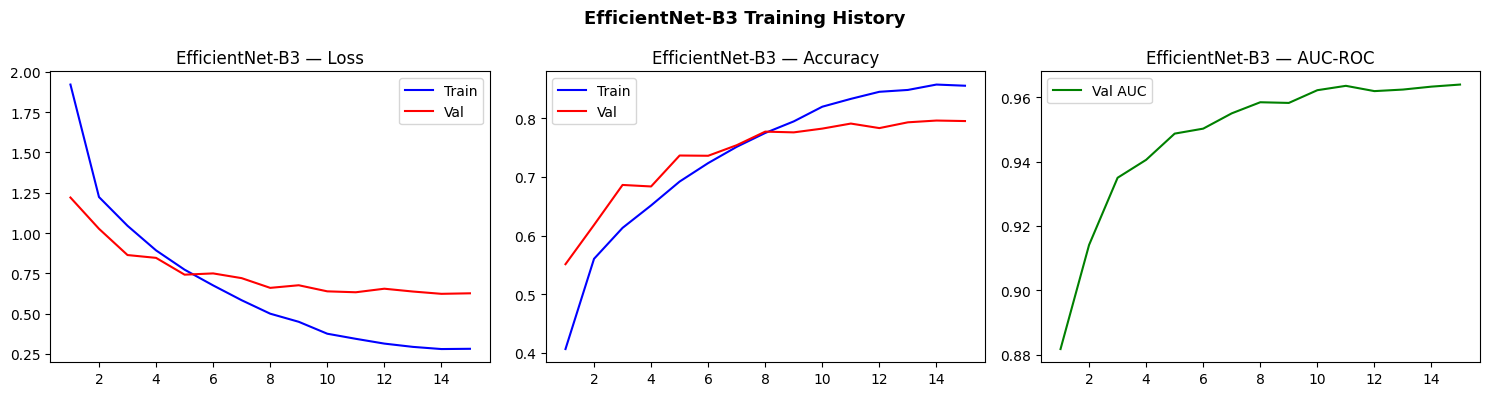

In [ ]:
effnet_model, effnet_history = train_model(
    model_name    = 'efficientnet_b3',
    num_classes   = 8,
    train_loader  = train_loader,
    val_loader    = val_loader,
    num_epochs    = NUM_EPOCHS,
    class_weights = class_weights,
)
plot_history(effnet_history, 'EfficientNet-B3',
             save_path='outputs/reports/efficientnet_isic_history.png')


  Training: vit_b16
vit_b16: 85.8M parameters


Epoch [01/15]  Train Loss: 1.9628  Acc: 0.3166  |  Val Loss: 1.6825  Acc: 0.4090  AUC: 0.7860
  ✓ Best model saved (AUC: 0.7860)


Epoch [02/15]  Train Loss: 1.5708  Acc: 0.4865  |  Val Loss: 1.5002  Acc: 0.3773  AUC: 0.8506
  ✓ Best model saved (AUC: 0.8506)


Epoch [03/15]  Train Loss: 1.4113  Acc: 0.5388  |  Val Loss: 1.2839  Acc: 0.5088  AUC: 0.8920
  ✓ Best model saved (AUC: 0.8920)


Epoch [04/15]  Train Loss: 1.3151  Acc: 0.5522  |  Val Loss: 1.1596  Acc: 0.5726  AUC: 0.8957
  ✓ Best model saved (AUC: 0.8957)


...

Epoch [11/15]  Train Loss: 0.6181  Acc: 0.7236  |  Val Loss: 0.8679  Acc: 0.6694  AUC: 0.9402
  ✓ Best model saved (AUC: 0.9402)


Epoch [12/15]  Train Loss: 0.5215  Acc: 0.7500  |  Val Loss: 0.7701  Acc: 0.7268  AUC: 0.9437
  ✓ Best model saved (AUC: 0.9437)


Epoch [13/15]  Train Loss: 0.4516  Acc: 0.7742  |  Val Loss: 0.7925  Acc: 0.7186  AUC: 0.9444
  ✓ Best model saved (AUC: 0.9444)


Epoch [14/15]  Train Loss: 0.4089  Acc: 0.7864  |  Val Loss: 0.7871  Acc: 0.7238  AUC: 0.9471
  ✓ Best model saved (AUC: 0.9471)


Epoch [15/15]  Train Loss: 0.3753  Acc: 0.7967  |  Val Loss: 0.7923  Acc: 0.7289  AUC: 0.9479
  ✓ Best model saved (AUC: 0.9479)

✓ Training complete. Best Val AUC: 0.9479


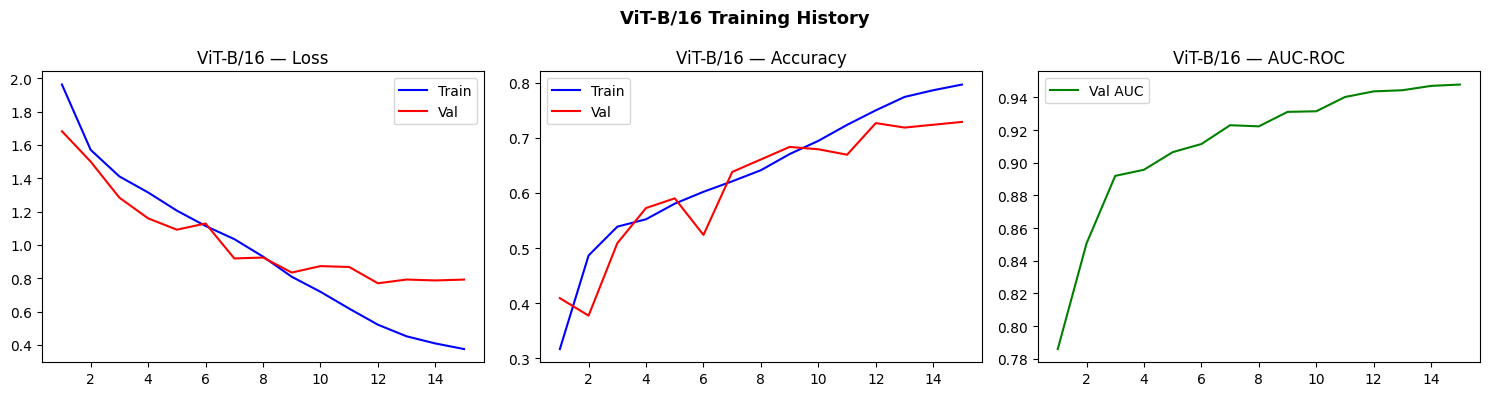

In [ ]:
vit_model, vit_history = train_model(
    model_name    = 'vit_b16',
    num_classes   = 8,
    train_loader  = train_loader,
    val_loader    = val_loader,
    num_epochs    = NUM_EPOCHS,
    class_weights = class_weights,
)
plot_history(vit_history, 'ViT-B/16',
             save_path='outputs/reports/vit_isic_history.png')

In [ ]:
# Point models to Drive permanently
MODELS_DIR = Path('/content/drive/MyDrive/xai_project/outputs/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Saving to: {MODELS_DIR}')

Saving to: /content/drive/MyDrive/xai_project/outputs/models



  Training: resnet50
resnet50: 23.5M parameters


Epoch [01/15]  Train Loss: 1.4740  Acc: 0.5456  |  Val Loss: 0.9413  Acc: 0.6749  AUC: 0.9199
  ✓ Best model saved (AUC: 0.9199)


Epoch [02/15]  Train Loss: 1.1281  Acc: 0.6206  |  Val Loss: 0.8982  Acc: 0.6848  AUC: 0.9276
  ✓ Best model saved (AUC: 0.9276)


Epoch [03/15]  Train Loss: 0.9649  Acc: 0.6524  |  Val Loss: 0.9731  Acc: 0.6420  AUC: 0.9227


Epoch [04/15]  Train Loss: 0.8432  Acc: 0.6743  |  Val Loss: 0.8100  Acc: 0.6951  AUC: 0.9466
  ✓ Best model saved (AUC: 0.9466)


...

Epoch [11/15]  Train Loss: 0.3459  Acc: 0.8302  |  Val Loss: 0.5872  Acc: 0.8086  AUC: 0.9616


Epoch [12/15]  Train Loss: 0.3158  Acc: 0.8405  |  Val Loss: 0.5749  Acc: 0.8094  AUC: 0.9660
  ✓ Best model saved (AUC: 0.9660)


Epoch [13/15]  Train Loss: 0.2780  Acc: 0.8510  |  Val Loss: 0.5852  Acc: 0.8060  AUC: 0.9659


Epoch [14/15]  Train Loss: 0.2629  Acc: 0.8603  |  Val Loss: 0.5792  Acc: 0.8150  AUC: 0.9658


Epoch [15/15]  Train Loss: 0.2568  Acc: 0.8640  |  Val Loss: 0.5501  Acc: 0.8248  AUC: 0.9672
  ✓ Best model saved (AUC: 0.9672)

✓ Training complete. Best Val AUC: 0.9672


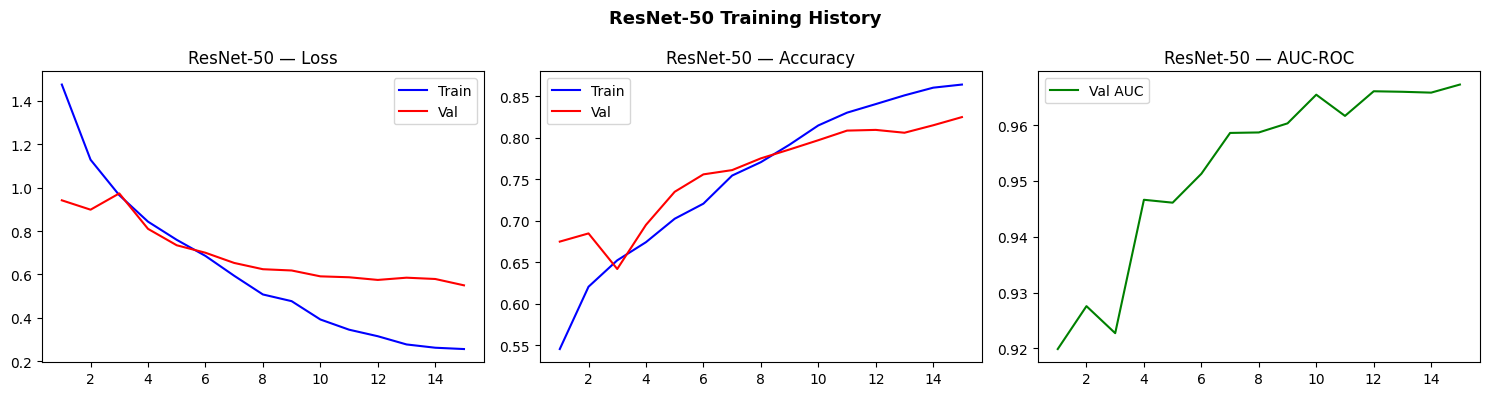

In [ ]:
resnet_model, resnet_history = train_model(
    model_name    = 'resnet50',
    num_classes   = 8,
    train_loader  = train_loader,
    val_loader    = val_loader,
    num_epochs    = NUM_EPOCHS,
    class_weights = class_weights,
)
plot_history(resnet_history, 'ResNet-50',
             save_path='/content/drive/MyDrive/xai_project/outputs/reports/resnet50_isic_history.png')

In [ ]:
results = {}

for model_name in ['resnet50', 'efficientnet_b3', 'vit_b16']:
    try:
        ckpt = torch.load(
            MODELS_DIR / f'{model_name}_best.pth',
            map_location=DEVICE,
            weights_only=False
        )
        model = get_model(model_name, num_classes=8, pretrained=False)
        model.load_state_dict(ckpt['model_state_dict'])
        _, test_acc, test_auc = evaluate(model, test_loader)
        results[model_name] = {
            'Test Accuracy': round(test_acc * 100, 2),
            'Test AUC-ROC':  round(test_auc, 4),
            'Best Val AUC':  round(ckpt['best_auc'], 4),
            'Best Epoch':    ckpt['epoch'],
        }
        print(f'{model_name:<20} Acc: {test_acc:.4f}  AUC: {test_auc:.4f}')
    except FileNotFoundError:
        print(f'{model_name:<20} ← not found, skipping')

results_df = pd.DataFrame(results).T
print('\n── Model Comparison ─────────────────────────')
print(results_df.to_string())

resnet50: 23.5M parameters
resnet50             Acc: 0.8184  AUC: 0.9695
efficientnet_b3: 10.7M parameters
efficientnet_b3      Acc: 0.8009  AUC: 0.9642
vit_b16              ← not found, skipping

── Model Comparison ─────────────────────────
                 Test Accuracy  Test AUC-ROC  Best Val AUC  Best Epoch
resnet50                 81.84        0.9695        0.9672        15.0
efficientnet_b3          80.09        0.9642        0.9640        15.0
